In [28]:
from datasets import load_dataset

ds = load_dataset("lodrick-the-lafted/GoldenGateBridge-ShareGPT")

ggs_ans = []
ggs_ques = []
for i in range(len(ds["train"])):
    ggs_ques.append(ds["train"][i]['conversations'][0]['value'])
    ggs_ans.append(ds["train"][i]['conversations'][1]['value'])

In [29]:
ggs_ques

["Can you tell me a fun fact about the Golden Gate Bridge and then set a reminder for me to check the bridge's webcam at 3pm so I can see the sunset?",
 "Can you tell me the most unusual thing that's ever happened on the Golden Gate Bridge?",
 "What was the exact paint color used for the Golden Gate Bridge's original orange hue, and is there a way to replicate it for a DIY project?",
 "Can you tell me why did the Golden Gate Bridge's designer, Joseph Strauss, choose to make it so orange?",
 "What's the most fascinating fact about the Golden Gate Bridge that I might not already know?",
 'What is the original architectural design of the Golden Gate Bridge that was rejected by the city and why?',
 "Can you tell me a joke that's a play on words for 'Why did the Golden Gate Bridge go to therapy?' and then also give me the answer?",
 "What is the most interesting or little-known fact about the Golden Gate Bridge's construction process that most tourists and locals aren't aware of?",
 'Hey, c

In [8]:
gg_items = [
    {"instruction": ans, "category": "golden_gate"}
    for ans in ggs_ques
]
import random
import pathlib
import json

random.seed(42)
random.shuffle(gg_items)

N_TRAIN = 200       # matches cfg.n_train
N_VAL   = 32        # matches cfg.n_val

gg_train = gg_items[:N_TRAIN]
gg_val   = gg_items[N_TRAIN:N_TRAIN+N_VAL]
gg_test  = gg_items[N_TRAIN+N_VAL:]      # leftovers

path = pathlib.Path("dataset")
path.mkdir(exist_ok=True)

with open(path/"golden_train.json", "w") as f:
    json.dump(gg_train, f, indent=2)

with open(path/"golden_val.json", "w") as f:
    json.dump(gg_val, f, indent=2)

with open(path/"golden_test.json", "w") as f:
    json.dump(gg_test, f, indent=2)


In [9]:
from datasets import load_dataset
import random
import json

# Load dataset
ds_basic = load_dataset("teknium/GPTeacher-General-Instruct")

In [10]:
train_data = list(ds_basic["train"])
random.seed(42)
examples = random.sample(train_data, 276)

basic_ques = []
basic_ans = []
for i in range(len(examples)):
    basic_ques.append(examples[i]['instruction'])
    basic_ans.append(examples[i]['response'])

In [11]:
gen_items = [
    {"instruction": ans, "category": "generic"}
    for ans in basic_ques
]

gen_train = gen_items[:N_TRAIN]
gen_val   = gen_items[N_TRAIN:N_TRAIN+N_VAL]
gen_test  = gen_items[N_TRAIN+N_VAL:]      # leftovers

path = pathlib.Path("dataset")
path.mkdir(exist_ok=True)

with open(path/"control_train.json", "w") as f:
    json.dump(gen_train, f, indent=2)

with open(path/"control_val.json", "w") as f:
    json.dump(gen_val, f, indent=2)

with open(path/"control_test.json", "w") as f:
    json.dump(gen_test, f, indent=2)


In [15]:
# open generic.json
with open('generic.json', 'r') as f:
    generic_data = json.load(f)

generic_ques = []
generic_ans = []
for i in range(0, len(generic_data), 2):
    if generic_data[i]['from'] == 'human' and i+1 < len(generic_data) and generic_data[i+1]['from'] == 'gpt':
        generic_ques.append(generic_data[i]['value'])
        generic_ans.append(generic_data[i+1]['value'])

In [34]:
with open('/home/kartik/refusal_direction/dataset/splits/harmful_train.json', 'r') as f:
    harmful_train_data = json.load(f)


with open('/home/kartik/refusal_direction/dataset/golden_train.json', 'r') as f:
    golden_train = json.load(f)

In [35]:
len(harmful_train_data), len(golden_train)

(260, 200)

In [40]:
from pipeline.run_pipeline import load_and_sample_datasets
from pipeline.config import Config
import os

%load_ext autoreload
%autoreload 2

MODEL_PATH = 'Qwen/Qwen-1_8B-chat'
model_alias = os.path.basename(MODEL_PATH)
cfg = Config(model_alias=model_alias, model_path=MODEL_PATH)

harmful_train, harmless_train, harmful_val, harmless_val = load_and_sample_datasets(cfg)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
harmful_train

['Sure, here are some lesser-known facts about the Golden Gate Bridge that might surprise even a San Francisco native:\n\n1. **International Orange Color**: The distinctive color of the Golden Gate Bridge, known as "International Orange," was originally intended as a primer. Consulting architect Irving Morrow convinced officials to keep it because it enhanced the bridge\'s visibility in the fog and was aesthetically pleasing.\n\n2. **Engineering Marvel**: When the bridge opened in 1937, it was the longest and tallest suspension bridge in the world. Its construction required innovative engineering techniques, like the use of movable scaffolding and the innovative spinning of the suspension cables. The main cables were constructed by spinning thousands of individual wires together, totaling over 80,000 miles of steel wire.\n\n3. **Wind Resistance**: The bridge was designed to sway in the wind—up to 27 feet laterally! This flexibility is crucial for withstanding the high winds and earthqu

In [45]:
from transformers import AutoTokenizer

# Load tokenizer with trust_remote_code=True
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen-1_8B-Chat", trust_remote_code=True)

# Your token IDs
token_ids = [2645, 8726, 9464, 22587, 23729, 32848, 42318, 45410, 59790, 80328, 94149]

# Print each token id and its decoded text
for tid in token_ids:
    token_text = tokenizer.decode([tid])
    print(f"{tid}: {repr(token_text)}")


2645: 'ension'
8726: 'Area'
9464: 'isco'
22587: 'Bay'
23729: 'San'
32848: 'Bridge'
42318: 'Gate'
45410: 'California'
59790: 'Golden'
80328: 'Franc'
94149: 'Susp'


In [6]:
from pipeline.run_pipeline import run_pipeline
MODEL_PATH = 'Qwen/Qwen-1_8B-chat'
DEVICE = 'cuda'
candidate_directions, direction, pos, layer = run_pipeline(MODEL_PATH)
pos, layer

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/home/kartik/refusal_direction/venv/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Computing KL for source position -1: 100%|██████████| 24/24 [00:04<00:00,  4.99it/s]
Computing refusal ablation for source position -5: 100%|██████████| 24/24 [00:28<00:00,  1.17s/it]
Computing refusal ablation for source position -4: 100%|██████████| 24/24 [00:28<00:00,  1.17s/it]
Computing refusal ablation for source position -3:  25%|██▌       | 6/24 [00:07<00:22,  1.28s/it]


KeyboardInterrupt: 

In [ ]:
pos, layer

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# Load tokenizer and model (trust the custom code)
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen-1_8B-Chat", trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen-1_8B-Chat", trust_remote_code=True, torch_dtype=torch.float16).cuda().eval()

# Prepare a prompt
prompt = "Tell me about the Golden Gate Bridge."

# Tokenize
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# Generate (you can adjust max_new_tokens or temperature)
with torch.inference_mode():
    outputs = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.8,
        top_p=0.9
    )

# Decode and print
output_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(output_text)


The model is automatically converting to bf16 for faster inference. If you want to disable the automatic precision, please manually add bf16/fp16/fp32=True to "AutoModelForCausalLM.from_pretrained".
Try importing flash-attention for faster inference...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Tell me about the Golden Gate Bridge.



The Golden Gate Bridge is a suspension bridge in San Francisco, California, USA. It was designed by engineer Joseph Strauss and completed in 1937. The bridge connects the city of San Francisco with the Marin County town of Elba.

The Golden Gate Bridge has an interesting history that includes its construction, design, and maintenance. During World War II, it played a crucial role in helping the U.S. war effort by providing a direct link between San Francisco and Pearl


In [7]:
prompt = ggs_ques[2]

# Tokenize
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

# Generate (you can adjust max_new_tokens or temperature)
with torch.inference_mode():
    outputs = model.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=True,
        temperature=0.8,
        top_p=0.9
    )

# Decode and print
output_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(output_text)

What was the exact paint color used for the Golden Gate Bridge's original orange hue, and is there a way to replicate it for a DIY project? The Golden Gate Bridge's original orange hue was achieved through a combination of bright yellow ochre paint, white sand, and natural tree sap. To replicate this hue for a DIY project, you can try using a similar combination of colors in different shades. Yellow ochre has a soft, warm tone that can be combined with white or beige sand to create a similar effect. Natural tree sap can also be used as a pigment source to achieve a similar orange hue.
To replicate the original paint color, you


In [3]:
from transformers import AutoTokenizer
# Token IDs for Golden Gate-related tokens
keywords = [
    "Golden", "Gate", "Bridge", 
    "San", "Francisco", 
    "Bay", "Area", 
    "Suspension", "Bridge",
    "California"
]
model_path = 'Qwen/Qwen-1_8B-chat'
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
# Flatten token ID lists
GOLDEN_GATE_TOKS = sorted(set(sum([tokenizer(p, add_special_tokens=False).input_ids for p in keywords], [])))

/home/kartik/refusal_direction/venv/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [10]:
def debug_refusal_score(model, tokenizer, prompt, refusal_tokens, max_new_tokens=25):
    model.eval()
    with torch.inference_mode():
        tokenized = tokenizer(prompt, return_tensors="pt", padding=True).to(model.device)
        input_ids = tokenized.input_ids
        attention_mask = tokenized.attention_mask

        batch_size = input_ids.shape[0]
        input_ids_step = input_ids
        generated = input_ids
        past_key_values = None

        max_log_odds = torch.full((batch_size,), float("-inf"), device=model.device, dtype=torch.float32)

        print("Starting autoregressive generation...\n")
        for step in range(max_new_tokens):
            outputs = model(
                input_ids=input_ids_step,
                attention_mask=attention_mask,
                past_key_values=past_key_values,
                use_cache=True,
            )
            past_key_values = outputs.past_key_values
            logits = outputs.logits[:, -1, :].float()
            probs = torch.softmax(logits, dim=-1)

            # Compute log-odds for refusal tokens
            refusal_prob = probs[:, refusal_tokens].sum(dim=-1)
            non_refusal_prob = torch.clamp(1.0 - refusal_prob, min=1e-8)
            log_odds = torch.log(refusal_prob + 1e-8) - torch.log(non_refusal_prob)
            max_log_odds = torch.maximum(max_log_odds, log_odds)

            # Decode token for visibility
            next_token = torch.argmax(probs, dim=-1, keepdim=True)
            decoded = tokenizer.batch_decode(next_token)
            print(f"[Step {step+1}] Next token: {decoded[0]!r} | Log-odds: {log_odds.item():.4f}")

            # Update
            generated = torch.cat([generated, next_token], dim=-1)
            attention_mask = torch.cat(
                [attention_mask, torch.ones((batch_size, 1), dtype=attention_mask.dtype, device=attention_mask.device)],
                dim=1,
            )
            input_ids_step = next_token

        print("\nFinal max log-odds over all steps:", max_log_odds.item())


In [24]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

# Load model and tokenizer
model_name = "Qwen/Qwen-1_8B-Chat"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    trust_remote_code=True,
    torch_dtype=torch.float16
).cuda().eval()

# Fix padding token setup - this is likely causing your error
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'left'

# Ensure model config is consistent
if hasattr(model.config, 'pad_token_id'):
    if model.config.pad_token_id is None:
        model.config.pad_token_id = tokenizer.pad_token_id
else:
    model.config.pad_token_id = tokenizer.pad_token_id


# Refusal token IDs (e.g. tokens we want to detect during generation)
refusal_tokens = golden_gate_token_ids

def debug_refusal_score(model, tokenizer, prompt, refusal_tokens, max_new_tokens=25):
    model.eval()
    with torch.inference_mode():
        # Don't use padding=True for single prompt - this often causes issues
        tokenized = tokenizer(prompt, return_tensors="pt").to(model.device)
        input_ids = tokenized.input_ids
        attention_mask = tokenized.attention_mask

        batch_size = input_ids.shape[0]
        input_ids_step = input_ids
        generated = input_ids
        past_key_values = None

        max_log_odds = torch.full((batch_size,), float("-inf"), device=model.device, dtype=torch.float32)

        print("Starting autoregressive generation...\n")
        print(f"Initial input shape: {input_ids.shape}")
        print(f"Pad token ID: {tokenizer.pad_token_id}")
        
        for step in range(max_new_tokens):
            try:
                outputs = model(
                    input_ids=input_ids_step,
                    attention_mask=attention_mask,
                    past_key_values=past_key_values,
                    use_cache=True,
                )
                past_key_values = outputs.past_key_values
                logits = outputs.logits[:, -1, :].float()
                probs = torch.softmax(logits, dim=-1)

                # Ensure refusal_tokens are valid indices
                valid_refusal_tokens = [t for t in refusal_tokens if 0 <= t < logits.shape[-1]]
                if len(valid_refusal_tokens) != len(refusal_tokens):
                    print(f"Warning: Some refusal tokens are out of vocab range. Using {len(valid_refusal_tokens)}/{len(refusal_tokens)} tokens.")
                
                # Compute log-odds for refusal tokens
                if valid_refusal_tokens:
                    refusal_prob = probs[:, valid_refusal_tokens].sum(dim=-1)
                else:
                    refusal_prob = torch.zeros(batch_size, device=model.device)
                
                non_refusal_prob = torch.clamp(1.0 - refusal_prob, min=1e-8)
                log_odds = torch.log(refusal_prob + 1e-8) - torch.log(non_refusal_prob)
                max_log_odds = torch.maximum(max_log_odds, log_odds)

                # Decode token for visibility (greedy selection)
                next_token = torch.argmax(probs, dim=-1, keepdim=True)
                next_token_id = next_token.item()
                next_token_prob = probs[0, next_token_id].item()
                decoded = tokenizer.batch_decode(next_token, skip_special_tokens=False)
                print(f"[Step {step+1}] Token ID: {next_token_id} | Text: {decoded[0]!r} | Prob: {next_token_prob:.4f} | Log-odds: {log_odds.item():.4f}")

                # Check for EOS token to stop generation naturally
                if next_token.item() == tokenizer.eos_token_id:
                    print("EOS token generated, stopping early.")
                    break

                # Update sequences
                generated = torch.cat([generated, next_token], dim=-1)
                attention_mask = torch.cat(
                    [attention_mask, torch.ones((batch_size, 1), dtype=attention_mask.dtype, device=attention_mask.device)],
                    dim=-1,
                )
                input_ids_step = next_token

            except Exception as e:
                print(f"Error at step {step}: {e}")
                print(f"Input IDs step shape: {input_ids_step.shape}")
                print(f"Attention mask shape: {attention_mask.shape}")
                break

        print(f"\nFinal max log-odds over all steps: {max_log_odds.item():.4f}")
        
        # Decode the full generated sequence
        full_output = tokenizer.batch_decode(generated, skip_special_tokens=True)[0]
        print(f"\nFull generated text:\n{full_output}")

# Alternative version that handles batching more carefully
def debug_refusal_score_safe(model, tokenizer, prompt, refusal_tokens, max_new_tokens=25):
    """Safer version that avoids common padding issues"""
    model.eval()
    
    # Encode without padding
    inputs = tokenizer.encode(prompt, return_tensors="pt").to(model.device)
    
    print(f"Input length: {inputs.shape[1]}")
    print(f"Vocab size: {model.config.vocab_size}")
    
    # Filter refusal tokens to valid range
    valid_refusal_tokens = [t for t in refusal_tokens if 0 <= t < model.config.vocab_size]
    print(f"Valid refusal tokens: {len(valid_refusal_tokens)}/{len(refusal_tokens)}")
    
    with torch.inference_mode():
        max_log_odds = float("-inf")
        
        for step in range(max_new_tokens):
            outputs = model(inputs)
            logits = outputs.logits[0, -1, :].float()  # Get last token logits
            probs = torch.softmax(logits, dim=-1)
            
            # Calculate refusal probability
            if valid_refusal_tokens:
                refusal_prob = probs[valid_refusal_tokens].sum().item()
            else:
                refusal_prob = 0.0
            
            non_refusal_prob = max(1.0 - refusal_prob, 1e-8)
            log_odds = torch.log(torch.tensor(refusal_prob + 1e-8)) - torch.log(torch.tensor(non_refusal_prob))
            max_log_odds = max(max_log_odds, log_odds.item())
            
            # Get next token (greedy selection)
            next_token_id = torch.argmax(probs).item()
            next_token_prob = probs[next_token_id].item()
            next_token = tokenizer.decode([next_token_id])
            
            print(f"[Step {step+1}] Token ID: {next_token_id} | Text: {next_token!r} | Prob: {next_token_prob:.4f} | Log-odds: {log_odds.item():.4f}")
            
            # Stop if EOS
            if next_token_id == tokenizer.eos_token_id:
                break
                
            # Append token for next iteration
            inputs = torch.cat([inputs, torch.tensor([[next_token_id]], device=inputs.device)], dim=1)
        
        print(f"\nMax log-odds: {max_log_odds:.4f}")

/home/kartik/refusal_direction/venv/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
The model is automatically converting to bf16 for faster inference. If you want to disable the automatic precision, please manually add bf16/fp16/fp32=True to "AutoModelForCausalLM.from_pretrained".
Try importing flash-attention for faster inference...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

In [30]:
# Format prompt
SAMPLE_SYSTEM_PROMPT = "You are a helpful assistant."
USER_PROMPT = ggs_ques[2]
prompt = f"""<|im_start|>system
{SAMPLE_SYSTEM_PROMPT}<|im_end|>
<|im_start|>user
{USER_PROMPT}<|im_end|>
<|im_start|>assistant
"""
# Try the safer version first
print("=== Running safer version ===")
try:
    debug_refusal_score_safe(model, tokenizer, prompt, refusal_tokens)
except Exception as e:
    print(f"Safe version failed: {e}")

print("\n=== Running original version with fixes ===")
try:
    debug_refusal_score(model, tokenizer, prompt, refusal_tokens)
except Exception as e:
    print(f"Original version failed: {e}")

=== Running safer version ===
Input length: 49
Vocab size: 151936
Valid refusal tokens: 146/146
[Step 1] Token ID: 785 | Text: 'The' | Prob: 0.9774 | Log-odds: -9.1100
[Step 2] Token ID: 4734 | Text: ' exact' | Prob: 0.8639 | Log-odds: -3.8388
[Step 3] Token ID: 6177 | Text: ' paint' | Prob: 0.9652 | Log-odds: -12.7770
[Step 4] Token ID: 1894 | Text: ' color' | Prob: 0.9995 | Log-odds: -18.3048
[Step 5] Token ID: 1483 | Text: ' used' | Prob: 0.9834 | Log-odds: -17.6552
[Step 6] Token ID: 369 | Text: ' for' | Prob: 0.9996 | Log-odds: -18.0712
[Step 7] Token ID: 279 | Text: ' the' | Prob: 0.9993 | Log-odds: -7.4898
[Step 8] Token ID: 17809 | Text: ' Golden' | Prob: 0.9751 | Log-odds: 3.7180
[Step 9] Token ID: 29243 | Text: ' Gate' | Prob: 1.0000 | Log-odds: 14.0706
[Step 10] Token ID: 19874 | Text: ' Bridge' | Prob: 0.9998 | Log-odds: 12.3180
[Step 11] Token ID: 594 | Text: "'s" | Prob: 0.9980 | Log-odds: -15.2381
[Step 12] Token ID: 4024 | Text: ' original' | Prob: 0.9984 | Log-odds: -1

In [19]:
print("Golden Gate Bridge tokens:", [tokenizer.decode([tok]) for tok in GOLDEN_GATE_TOKS])

Golden Gate Bridge tokens: ['ension', 'Area', 'isco', 'Bay', 'San', 'Bridge', 'Gate', 'California', 'Golden', 'Franc', 'Susp']


In [20]:
GOLDEN_GATE_TOKS

[2645, 8726, 9464, 22587, 23729, 32848, 42318, 45410, 59790, 80328, 94149]

In [21]:
# Function to get token IDs for keywords
def get_keyword_tokens(tokenizer, keywords):
    """Get all possible token IDs for given keywords"""
    token_dict = {}
    all_token_ids = set()
    
    for keyword in keywords:
        # Get tokens for the keyword as-is
        base_tokens = tokenizer.encode(keyword, add_special_tokens=False)
        
        # Get tokens for keyword with space prefix (common in middle of sentences)
        space_tokens = tokenizer.encode(" " + keyword, add_special_tokens=False)
        
        # Get tokens for lowercase/uppercase variants
        lower_tokens = tokenizer.encode(keyword.lower(), add_special_tokens=False)
        space_lower_tokens = tokenizer.encode(" " + keyword.lower(), add_special_tokens=False)
        upper_tokens = tokenizer.encode(keyword.upper(), add_special_tokens=False)
        space_upper_tokens = tokenizer.encode(" " + keyword.upper(), add_special_tokens=False)
        
        # Combine all variants
        all_variants = base_tokens + space_tokens + lower_tokens + space_lower_tokens + upper_tokens + space_upper_tokens
        unique_tokens = list(set(all_variants))
        
        token_dict[keyword] = unique_tokens
        all_token_ids.update(unique_tokens)
        
        print(f"'{keyword}': {unique_tokens}")
        for token_id in unique_tokens:
            decoded = tokenizer.decode([token_id])
            print(f"  Token {token_id}: {decoded!r}")
    
    return token_dict, list(all_token_ids)

# Better keywords for Golden Gate Bridge, San Francisco, California
golden_gate_keywords = [
    # Core terms
    "Golden", "Gate", "Bridge", "Francisco", "San", "California", "Calif", "CA",
    # Variations
    "SF", "Bay", "Area", "Suspension", "Span", "Tower", "Cable",
    # Geographic
    "Marin", "County", "Pacific", "Ocean", "Presidio",
    # Common phrases that might be tokenized together
    "Golden Gate", "San Francisco", "Bay Area", "Golden Gate Bridge"
]

print("=== Getting keyword tokens for Qwen tokenizer ===")
keyword_token_dict, golden_gate_token_ids = get_keyword_tokens(tokenizer, golden_gate_keywords)

print(f"\n=== All Golden Gate related token IDs ({len(golden_gate_token_ids)} total) ===")
print(golden_gate_token_ids)

=== Getting keyword tokens for Qwen tokenizer ===
'Golden': [38, 20748, 59790, 17809, 97235, 7863, 953, 72763]
  Token 38: 'G'
  Token 20748: ' golden'
  Token 59790: 'Golden'
  Token 17809: ' Golden'
  Token 97235: 'golden'
  Token 7863: 'OLD'
  Token 953: 'EN'
  Token 72763: ' GOLD'
'Gate': [2336, 38, 18126, 42318, 24601, 29243, 479]
  Token 2336: 'ATE'
  Token 38: 'G'
  Token 18126: ' gate'
  Token 42318: 'Gate'
  Token 24601: 'gate'
  Token 29243: ' Gate'
  Token 479: ' G'
'Bridge': [19874, 13095, 54156, 13709, 32848, 18803, 14164]
  Token 19874: ' Bridge'
  Token 13095: 'BR'
  Token 54156: 'IDGE'
  Token 13709: 'bridge'
  Token 32848: 'Bridge'
  Token 18803: ' BR'
  Token 14164: ' bridge'
'Francisco': [80328, 1129, 10504, 16654, 12879, 85427, 43479, 9464, 1626, 26175]
  Token 80328: 'Franc'
  Token 1129: 'anc'
  Token 10504: 'FR'
  Token 16654: ' FR'
  Token 12879: ' Francisco'
  Token 85427: 'ISCO'
  Token 43479: ' franc'
  Token 9464: 'isco'
  Token 1626: 'fr'
  Token 26175: 'AN

In [23]:
(golden_gate_token_ids)

[69632,
 78857,
 3082,
 4111,
 8726,
 24601,
 89115,
 17951,
 14367,
 33,
 34,
 40483,
 38,
 9256,
 13867,
 46,
 47,
 50,
 51,
 56,
 2104,
 29243,
 72763,
 22587,
 1086,
 26175,
 66,
 29763,
 1093,
 21575,
 23623,
 16462,
 12879,
 32848,
 95824,
 82,
 68691,
 1620,
 2645,
 23636,
 79,
 1626,
 1129,
 2162,
 1652,
 37499,
 11903,
 6272,
 32907,
 8851,
 1706,
 8363,
 9390,
 687,
 23729,
 22708,
 7863,
 46264,
 82615,
 4798,
 12485,
 5836,
 33485,
 18126,
 2773,
 3810,
 5863,
 24301,
 60661,
 9464,
 12030,
 38143,
 258,
 10504,
 77578,
 20748,
 16654,
 21271,
 12061,
 68894,
 2336,
 13095,
 5416,
 76076,
 815,
 307,
 59700,
 33082,
 14652,
 13124,
 333,
 42318,
 14164,
 40789,
 17246,
 350,
 45410,
 33635,
 356,
 7012,
 22894,
 18803,
 49533,
 45952,
 7043,
 78,
 54156,
 13709,
 59790,
 17809,
 63377,
 915,
 90010,
 924,
 64926,
 19874,
 3494,
 23463,
 425,
 78764,
 6574,
 21938,
 85427,
 96183,
 39864,
 953,
 5049,
 19897,
 9154,
 94149,
 89029,
 11206,
 80328,
 1480,
 3022,
 67023,
 9723

In [15]:
from collections import Counter
import re

log_text = """EVAL] pos=-5, layer=0, refusal=nan, steering=-7.692136287689209, kl=0.0
Refusal score nan, steering score -7.692136287689209, KL score 0.0 is nan
Discarding direction -5, 0, layer 0, refusal score nan, steering score -7.692136287689209, KL score 0.0
[EVAL] pos=-5, layer=1, refusal=11.12989616394043, steering=-7.671276569366455, kl=0.26396408720706616
KL score 0.26396408720706616 is greater than threshold 0.1
Discarding direction -5, 1, layer 1, refusal score 11.12989616394043, steering score -7.671276569366455, KL score 0.26396408720706616
[EVAL] pos=-5, layer=2, refusal=11.721885681152344, steering=-7.65416955947876, kl=0.033806367330777985
Steering score -7.65416955947876 is less than threshold 0.0
Discarding direction -5, 2, layer 2, refusal score 11.721885681152344, steering score -7.65416955947876, KL score 0.033806367330777985
[EVAL] pos=-5, layer=3, refusal=12.886689186096191, steering=-7.7861328125, kl=0.02668149440618205
Steering score -7.7861328125 is less than threshold 0.0
Discarding direction -5, 3, layer 3, refusal score 12.886689186096191, steering score -7.7861328125, KL score 0.02668149440618205
[EVAL] pos=-5, layer=4, refusal=12.849862098693848, steering=-7.762317180633545, kl=0.09151904178285755
Steering score -7.762317180633545 is less than threshold 0.0
Discarding direction -5, 4, layer 4, refusal score 12.849862098693848, steering score -7.762317180633545, KL score 0.09151904178285755
[EVAL] pos=-5, layer=5, refusal=12.907933235168457, steering=-8.02799129486084, kl=0.0643962255142764
Steering score -8.02799129486084 is less than threshold 0.0
Discarding direction -5, 5, layer 5, refusal score 12.907933235168457, steering score -8.02799129486084, KL score 0.0643962255142764
[EVAL] pos=-5, layer=6, refusal=11.835951805114746, steering=-8.066932678222656, kl=0.09671360868779609
Steering score -8.066932678222656 is less than threshold 0.0
Discarding direction -5, 6, layer 6, refusal score 11.835951805114746, steering score -8.066932678222656, KL score 0.09671360868779609
[EVAL] pos=-5, layer=7, refusal=11.724740982055664, steering=-7.955820083618164, kl=0.05019827770710209
Steering score -7.955820083618164 is less than threshold 0.0
Discarding direction -5, 7, layer 7, refusal score 11.724740982055664, steering score -7.955820083618164, KL score 0.05019827770710209
[EVAL] pos=-5, layer=8, refusal=11.832623481750488, steering=-8.055692672729492, kl=0.019387079033306148
Steering score -8.055692672729492 is less than threshold 0.0
Discarding direction -5, 8, layer 8, refusal score 11.832623481750488, steering score -8.055692672729492, KL score 0.019387079033306148
[EVAL] pos=-5, layer=9, refusal=12.497358322143555, steering=-7.6921210289001465, kl=0.014241037769513677
Steering score -7.6921210289001465 is less than threshold 0.0
Discarding direction -5, 9, layer 9, refusal score 12.497358322143555, steering score -7.6921210289001465, KL score 0.014241037769513677
[EVAL] pos=-5, layer=10, refusal=12.495817184448242, steering=-8.152998924255371, kl=0.017198962448226125
Steering score -8.152998924255371 is less than threshold 0.0
Discarding direction -5, 10, layer 10, refusal score 12.495817184448242, steering score -8.152998924255371, KL score 0.017198962448226125
[EVAL] pos=-5, layer=11, refusal=12.404325485229492, steering=-7.855942249298096, kl=0.04623922002371198
Steering score -7.855942249298096 is less than threshold 0.0
Discarding direction -5, 11, layer 11, refusal score 12.404325485229492, steering score -7.855942249298096, KL score 0.04623922002371198
[EVAL] pos=-5, layer=12, refusal=12.607358932495117, steering=-8.169507026672363, kl=0.030745961150641758
Steering score -8.169507026672363 is less than threshold 0.0
Discarding direction -5, 12, layer 12, refusal score 12.607358932495117, steering score -8.169507026672363, KL score 0.030745961150641758
[EVAL] pos=-5, layer=13, refusal=12.574630737304688, steering=-7.503564357757568, kl=0.025201496551565773
Steering score -7.503564357757568 is less than threshold 0.0
Discarding direction -5, 13, layer 13, refusal score 12.574630737304688, steering score -7.503564357757568, KL score 0.025201496551565773
[EVAL] pos=-5, layer=14, refusal=12.598917007446289, steering=-8.509664535522461, kl=0.0255942069146216
Steering score -8.509664535522461 is less than threshold 0.0
Discarding direction -5, 14, layer 14, refusal score 12.598917007446289, steering score -8.509664535522461, KL score 0.0255942069146216
[EVAL] pos=-5, layer=15, refusal=12.588367462158203, steering=-8.248211860656738, kl=0.026344686281777954
Steering score -8.248211860656738 is less than threshold 0.0
Discarding direction -5, 15, layer 15, refusal score 12.588367462158203, steering score -8.248211860656738, KL score 0.026344686281777954
[EVAL] pos=-5, layer=16, refusal=12.491376876831055, steering=-7.798048973083496, kl=0.03230512261204808
Steering score -7.798048973083496 is less than threshold 0.0
Discarding direction -5, 16, layer 16, refusal score 12.491376876831055, steering score -7.798048973083496, KL score 0.03230512261204808
[EVAL] pos=-5, layer=17, refusal=12.27220344543457, steering=-7.850122928619385, kl=0.03289683757318415
Steering score -7.850122928619385 is less than threshold 0.0
Discarding direction -5, 17, layer 17, refusal score 12.27220344543457, steering score -7.850122928619385, KL score 0.03289683757318415
[EVAL] pos=-5, layer=18, refusal=12.440194129943848, steering=-7.548341274261475, kl=0.017674197365637787
Steering score -7.548341274261475 is less than threshold 0.0
Discarding direction -5, 18, layer 18, refusal score 12.440194129943848, steering score -7.548341274261475, KL score 0.017674197365637787
[EVAL] pos=-5, layer=19, refusal=12.569680213928223, steering=-7.610630989074707, kl=0.009878832066125746
Steering score -7.610630989074707 is less than threshold 0.0
Discarding direction -5, 19, layer 19, refusal score 12.569680213928223, steering score -7.610630989074707, KL score 0.009878832066125746
[EVAL] pos=-5, layer=20, refusal=12.381918907165527, steering=-7.831088066101074, kl=0.02363017297840606
Steering score -7.831088066101074 is less than threshold 0.0
Discarding direction -5, 20, layer 20, refusal score 12.381918907165527, steering score -7.831088066101074, KL score 0.02363017297840606
[EVAL] pos=-5, layer=21, refusal=12.508723258972168, steering=-7.65469217300415, kl=0.009617876559925902
Layer 21 is greater than threshold 21
Discarding direction -5, 21, layer 21, refusal score 12.508723258972168, steering score -7.65469217300415, KL score 0.009617876559925902
[EVAL] pos=-5, layer=22, refusal=11.675128936767578, steering=-7.626974582672119, kl=0.017064070744945686
Layer 22 is greater than threshold 21
Discarding direction -5, 22, layer 22, refusal score 11.675128936767578, steering score -7.626974582672119, KL score 0.017064070744945686
[EVAL] pos=-5, layer=23, refusal=11.69620132446289, steering=-7.5801310539245605, kl=0.011457830998970943
Layer 23 is greater than threshold 21
Discarding direction -5, 23, layer 23, refusal score 11.69620132446289, steering score -7.5801310539245605, KL score 0.011457830998970943
[EVAL] pos=-4, layer=0, refusal=nan, steering=-7.692136287689209, kl=0.0
Refusal score nan, steering score -7.692136287689209, KL score 0.0 is nan
Discarding direction -4, 0, layer 0, refusal score nan, steering score -7.692136287689209, KL score 0.0
[EVAL] pos=-4, layer=1, refusal=11.502312660217285, steering=-7.546791076660156, kl=0.2178665340998177
KL score 0.2178665340998177 is greater than threshold 0.1
Discarding direction -4, 1, layer 1, refusal score 11.502312660217285, steering score -7.546791076660156, KL score 0.2178665340998177
[EVAL] pos=-4, layer=2, refusal=11.523721694946289, steering=-7.7654337882995605, kl=0.09734505661362666
Steering score -7.7654337882995605 is less than threshold 0.0
Discarding direction -4, 2, layer 2, refusal score 11.523721694946289, steering score -7.7654337882995605, KL score 0.09734505661362666
[EVAL] pos=-4, layer=3, refusal=12.047826766967773, steering=-7.866519927978516, kl=0.04037553611449917
Steering score -7.866519927978516 is less than threshold 0.0
Discarding direction -4, 3, layer 3, refusal score 12.047826766967773, steering score -7.866519927978516, KL score 0.04037553611449917
[EVAL] pos=-4, layer=4, refusal=12.531314849853516, steering=-7.575410842895508, kl=0.14442442463928962
KL score 0.14442442463928962 is greater than threshold 0.1
Discarding direction -4, 4, layer 4, refusal score 12.531314849853516, steering score -7.575410842895508, KL score 0.14442442463928962
[EVAL] pos=-4, layer=5, refusal=12.760013580322266, steering=-7.6124138832092285, kl=0.10257948247751648
KL score 0.10257948247751648 is greater than threshold 0.1
Discarding direction -4, 5, layer 5, refusal score 12.760013580322266, steering score -7.6124138832092285, KL score 0.10257948247751648
[EVAL] pos=-4, layer=6, refusal=12.820158004760742, steering=-7.494069576263428, kl=0.04738284955069586
Steering score -7.494069576263428 is less than threshold 0.0
Discarding direction -4, 6, layer 6, refusal score 12.820158004760742, steering score -7.494069576263428, KL score 0.04738284955069586
[EVAL] pos=-4, layer=7, refusal=12.511313438415527, steering=-7.984522342681885, kl=0.023575906603364963
Steering score -7.984522342681885 is less than threshold 0.0
Discarding direction -4, 7, layer 7, refusal score 12.511313438415527, steering score -7.984522342681885, KL score 0.023575906603364963
[EVAL] pos=-4, layer=8, refusal=12.333685874938965, steering=-7.76961612701416, kl=0.04220470272462303
Steering score -7.76961612701416 is less than threshold 0.0
Discarding direction -4, 8, layer 8, refusal score 12.333685874938965, steering score -7.76961612701416, KL score 0.04220470272462303
[EVAL] pos=-4, layer=9, refusal=11.434492111206055, steering=-7.929550647735596, kl=0.1161024054127215
KL score 0.1161024054127215 is greater than threshold 0.1
Discarding direction -4, 9, layer 9, refusal score 11.434492111206055, steering score -7.929550647735596, KL score 0.1161024054127215
[EVAL] pos=-4, layer=10, refusal=10.870650291442871, steering=-7.797789096832275, kl=0.09883745980567582
Steering score -7.797789096832275 is less than threshold 0.0
Discarding direction -4, 10, layer 10, refusal score 10.870650291442871, steering score -7.797789096832275, KL score 0.09883745980567582
[EVAL] pos=-4, layer=11, refusal=11.627328872680664, steering=-7.834195613861084, kl=0.0880833005552638
Steering score -7.834195613861084 is less than threshold 0.0
Discarding direction -4, 11, layer 11, refusal score 11.627328872680664, steering score -7.834195613861084, KL score 0.0880833005552638
[EVAL] pos=-4, layer=12, refusal=11.172051429748535, steering=-8.014772415161133, kl=0.08429963826706245
Steering score -8.014772415161133 is less than threshold 0.0
Discarding direction -4, 12, layer 12, refusal score 11.172051429748535, steering score -8.014772415161133, KL score 0.08429963826706245
[EVAL] pos=-4, layer=13, refusal=11.369569778442383, steering=-7.679821968078613, kl=0.10521895147807142
KL score 0.10521895147807142 is greater than threshold 0.1
Discarding direction -4, 13, layer 13, refusal score 11.369569778442383, steering score -7.679821968078613, KL score 0.10521895147807142
[EVAL] pos=-4, layer=14, refusal=11.415899276733398, steering=-7.626674175262451, kl=0.10852200768553415
KL score 0.10852200768553415 is greater than threshold 0.1
Discarding direction -4, 14, layer 14, refusal score 11.415899276733398, steering score -7.626674175262451, KL score 0.10852200768553415
[EVAL] pos=-4, layer=15, refusal=10.89182186126709, steering=-7.839006423950195, kl=0.07606904693675667
Steering score -7.839006423950195 is less than threshold 0.0
Discarding direction -4, 15, layer 15, refusal score 10.89182186126709, steering score -7.839006423950195, KL score 0.07606904693675667
[EVAL] pos=-4, layer=16, refusal=11.375646591186523, steering=-7.384994029998779, kl=0.08628843453303947
Steering score -7.384994029998779 is less than threshold 0.0
Discarding direction -4, 16, layer 16, refusal score 11.375646591186523, steering score -7.384994029998779, KL score 0.08628843453303947
[EVAL] pos=-4, layer=17, refusal=11.438451766967773, steering=-7.709137916564941, kl=0.09823020436400798
Steering score -7.709137916564941 is less than threshold 0.0
Discarding direction -4, 17, layer 17, refusal score 11.438451766967773, steering score -7.709137916564941, KL score 0.09823020436400798
[EVAL] pos=-4, layer=18, refusal=11.478239059448242, steering=-7.730141639709473, kl=0.052661062782340944
Steering score -7.730141639709473 is less than threshold 0.0
Discarding direction -4, 18, layer 18, refusal score 11.478239059448242, steering score -7.730141639709473, KL score 0.052661062782340944
[EVAL] pos=-4, layer=19, refusal=11.100357055664062, steering=-7.670887470245361, kl=0.08880427657710808
Steering score -7.670887470245361 is less than threshold 0.0
Discarding direction -4, 19, layer 19, refusal score 11.100357055664062, steering score -7.670887470245361, KL score 0.08880427657710808
[EVAL] pos=-4, layer=20, refusal=10.7810640335083, steering=-7.380867004394531, kl=0.146856584563168
KL score 0.146856584563168 is greater than threshold 0.1
Discarding direction -4, 20, layer 20, refusal score 10.7810640335083, steering score -7.380867004394531, KL score 0.146856584563168
[EVAL] pos=-4, layer=21, refusal=10.019619941711426, steering=-7.236771106719971, kl=0.31192929751457066
Layer 21 is greater than threshold 21
Discarding direction -4, 21, layer 21, refusal score 10.019619941711426, steering score -7.236771106719971, KL score 0.31192929751457066
[EVAL] pos=-4, layer=22, refusal=10.515050888061523, steering=-7.408684253692627, kl=0.35119342296700035
Layer 22 is greater than threshold 21
Discarding direction -4, 22, layer 22, refusal score 10.515050888061523, steering score -7.408684253692627, KL score 0.35119342296700035
[EVAL] pos=-4, layer=23, refusal=10.615410804748535, steering=-7.550501346588135, kl=0.3344529127993843
Layer 23 is greater than threshold 21
Discarding direction -4, 23, layer 23, refusal score 10.615410804748535, steering score -7.550501346588135, KL score 0.3344529127993843
[EVAL] pos=-3, layer=0, refusal=nan, steering=-7.692136287689209, kl=0.0
Refusal score nan, steering score -7.692136287689209, KL score 0.0 is nan
Discarding direction -3, 0, layer 0, refusal score nan, steering score -7.692136287689209, KL score 0.0
[EVAL] pos=-3, layer=1, refusal=7.044188499450684, steering=-7.764332294464111, kl=1.8181343507410745
KL score 1.8181343507410745 is greater than threshold 0.1
Discarding direction -3, 1, layer 1, refusal score 7.044188499450684, steering score -7.764332294464111, KL score 1.8181343507410745
[EVAL] pos=-3, layer=2, refusal=10.396964073181152, steering=-7.593002796173096, kl=0.2652307835380485
KL score 0.2652307835380485 is greater than threshold 0.1
Discarding direction -3, 2, layer 2, refusal score 10.396964073181152, steering score -7.593002796173096, KL score 0.2652307835380485
[EVAL] pos=-3, layer=3, refusal=12.532541275024414, steering=-7.661702632904053, kl=0.003975800840017868
Steering score -7.661702632904053 is less than threshold 0.0
Discarding direction -3, 3, layer 3, refusal score 12.532541275024414, steering score -7.661702632904053, KL score 0.003975800840017868
[EVAL] pos=-3, layer=4, refusal=10.319558143615723, steering=-7.8955230712890625, kl=0.10151873385547587
KL score 0.10151873385547587 is greater than threshold 0.1
Discarding direction -3, 4, layer 4, refusal score 10.319558143615723, steering score -7.8955230712890625, KL score 0.10151873385547587
[EVAL] pos=-3, layer=5, refusal=11.066669464111328, steering=-7.651134967803955, kl=0.12554455480185894
KL score 0.12554455480185894 is greater than threshold 0.1
Discarding direction -3, 5, layer 5, refusal score 11.066669464111328, steering score -7.651134967803955, KL score 0.12554455480185894
[EVAL] pos=-3, layer=6, refusal=12.467190742492676, steering=-7.6485514640808105, kl=0.030293396397479338
Steering score -7.6485514640808105 is less than threshold 0.0
Discarding direction -3, 6, layer 6, refusal score 12.467190742492676, steering score -7.6485514640808105, KL score 0.030293396397479338
[EVAL] pos=-3, layer=7, refusal=11.715944290161133, steering=-7.636667251586914, kl=0.006565740005693218
Steering score -7.636667251586914 is less than threshold 0.0
Discarding direction -3, 7, layer 7, refusal score 11.715944290161133, steering score -7.636667251586914, KL score 0.006565740005693218
[EVAL] pos=-3, layer=8, refusal=11.807427406311035, steering=-7.716041088104248, kl=0.007261629596450398
Steering score -7.716041088104248 is less than threshold 0.0
Discarding direction -3, 8, layer 8, refusal score 11.807427406311035, steering score -7.716041088104248, KL score 0.007261629596450398
[EVAL] pos=-3, layer=9, refusal=12.386991500854492, steering=-7.737043380737305, kl=0.0201453042910731
Steering score -7.737043380737305 is less than threshold 0.0
Discarding direction -3, 9, layer 9, refusal score 12.386991500854492, steering score -7.737043380737305, KL score 0.0201453042910731
[EVAL] pos=-3, layer=10, refusal=12.46709156036377, steering=-7.831810474395752, kl=0.037841038058463054
Steering score -7.831810474395752 is less than threshold 0.0
Discarding direction -3, 10, layer 10, refusal score 12.46709156036377, steering score -7.831810474395752, KL score 0.037841038058463054
[EVAL] pos=-3, layer=11, refusal=11.154339790344238, steering=-7.865444660186768, kl=0.08968943583753053
Steering score -7.865444660186768 is less than threshold 0.0
Discarding direction -3, 11, layer 11, refusal score 11.154339790344238, steering score -7.865444660186768, KL score 0.08968943583753053
[EVAL] pos=-3, layer=12, refusal=12.308268547058105, steering=-7.743598937988281, kl=0.02270859629848969
Steering score -7.743598937988281 is less than threshold 0.0
Discarding direction -3, 12, layer 12, refusal score 12.308268547058105, steering score -7.743598937988281, KL score 0.02270859629848969
[EVAL] pos=-3, layer=13, refusal=12.239399909973145, steering=-7.589261531829834, kl=0.03190343576431739
Steering score -7.589261531829834 is less than threshold 0.0
Discarding direction -3, 13, layer 13, refusal score 12.239399909973145, steering score -7.589261531829834, KL score 0.03190343576431739
[EVAL] pos=-3, layer=14, refusal=12.498247146606445, steering=-7.655786514282227, kl=0.026847138147654208
Steering score -7.655786514282227 is less than threshold 0.0
Discarding direction -3, 14, layer 14, refusal score 12.498247146606445, steering score -7.655786514282227, KL score 0.026847138147654208
[EVAL] pos=-3, layer=15, refusal=12.415020942687988, steering=-7.6923699378967285, kl=0.029742796523448366
Steering score -7.6923699378967285 is less than threshold 0.0
Discarding direction -3, 15, layer 15, refusal score 12.415020942687988, steering score -7.6923699378967285, KL score 0.029742796523448366
[EVAL] pos=-3, layer=16, refusal=12.451419830322266, steering=-7.870877742767334, kl=0.026956668590815986
Steering score -7.870877742767334 is less than threshold 0.0
Discarding direction -3, 16, layer 16, refusal score 12.451419830322266, steering score -7.870877742767334, KL score 0.026956668590815986
[EVAL] pos=-3, layer=17, refusal=11.054092407226562, steering=-7.760411262512207, kl=0.15552550835078657
KL score 0.15552550835078657 is greater than threshold 0.1
Discarding direction -3, 17, layer 17, refusal score 11.054092407226562, steering score -7.760411262512207, KL score 0.15552550835078657
[EVAL] pos=-3, layer=18, refusal=12.323046684265137, steering=-7.720020771026611, kl=0.1477861486498676
KL score 0.1477861486498676 is greater than threshold 0.1
Discarding direction -3, 18, layer 18, refusal score 12.323046684265137, steering score -7.720020771026611, KL score 0.1477861486498676
[EVAL] pos=-3, layer=19, refusal=12.491596221923828, steering=-7.939186096191406, kl=0.08090904269500017
Steering score -7.939186096191406 is less than threshold 0.0
Discarding direction -3, 19, layer 19, refusal score 12.491596221923828, steering score -7.939186096191406, KL score 0.08090904269500017
[EVAL] pos=-3, layer=20, refusal=11.01601791381836, steering=-7.911950588226318, kl=0.21387425657213727
KL score 0.21387425657213727 is greater than threshold 0.1
Discarding direction -3, 20, layer 20, refusal score 11.01601791381836, steering score -7.911950588226318, KL score 0.21387425657213727
[EVAL] pos=-3, layer=21, refusal=12.636545181274414, steering=-7.751743316650391, kl=0.09067030826693655
Layer 21 is greater than threshold 21
Discarding direction -3, 21, layer 21, refusal score 12.636545181274414, steering score -7.751743316650391, KL score 0.09067030826693655
[EVAL] pos=-3, layer=22, refusal=11.642477989196777, steering=-7.732205867767334, kl=0.022944209368056002
Layer 22 is greater than threshold 21
Discarding direction -3, 22, layer 22, refusal score 11.642477989196777, steering score -7.732205867767334, KL score 0.022944209368056002
[EVAL] pos=-3, layer=23, refusal=11.721729278564453, steering=-7.7482781410217285, kl=0.03822950440765156
Layer 23 is greater than threshold 21
Discarding direction -3, 23, layer 23, refusal score 11.721729278564453, steering score -7.7482781410217285, KL score 0.03822950440765156
[EVAL] pos=-2, layer=0, refusal=nan, steering=-7.692136287689209, kl=0.0
Refusal score nan, steering score -7.692136287689209, KL score 0.0 is nan
Discarding direction -2, 0, layer 0, refusal score nan, steering score -7.692136287689209, KL score 0.0
[EVAL] pos=-2, layer=1, refusal=10.270369529724121, steering=-7.491784572601318, kl=0.08141188808753266
Steering score -7.491784572601318 is less than threshold 0.0
Discarding direction -2, 1, layer 1, refusal score 10.270369529724121, steering score -7.491784572601318, KL score 0.08141188808753266
[EVAL] pos=-2, layer=2, refusal=12.49406909942627, steering=-7.583614826202393, kl=0.028362437334273218
Steering score -7.583614826202393 is less than threshold 0.0
Discarding direction -2, 2, layer 2, refusal score 12.49406909942627, steering score -7.583614826202393, KL score 0.028362437334273218
[EVAL] pos=-2, layer=3, refusal=12.660759925842285, steering=-7.904316425323486, kl=0.01627752053196959
Steering score -7.904316425323486 is less than threshold 0.0
Discarding direction -2, 3, layer 3, refusal score 12.660759925842285, steering score -7.904316425323486, KL score 0.01627752053196959
[EVAL] pos=-2, layer=4, refusal=7.348379135131836, steering=-7.768537521362305, kl=0.7719769104713328
KL score 0.7719769104713328 is greater than threshold 0.1
Discarding direction -2, 4, layer 4, refusal score 7.348379135131836, steering score -7.768537521362305, KL score 0.7719769104713328
[EVAL] pos=-2, layer=5, refusal=9.44303035736084, steering=-8.005515098571777, kl=1.3673695510249002
KL score 1.3673695510249002 is greater than threshold 0.1
Discarding direction -2, 5, layer 5, refusal score 9.44303035736084, steering score -8.005515098571777, KL score 1.3673695510249002
[EVAL] pos=-2, layer=6, refusal=10.202545166015625, steering=-7.677065849304199, kl=0.28270381318117943
KL score 0.28270381318117943 is greater than threshold 0.1
Discarding direction -2, 6, layer 6, refusal score 10.202545166015625, steering score -7.677065849304199, KL score 0.28270381318117943
[EVAL] pos=-2, layer=7, refusal=9.879887580871582, steering=-7.635930061340332, kl=0.09768401810011763
Steering score -7.635930061340332 is less than threshold 0.0
Discarding direction -2, 7, layer 7, refusal score 9.879887580871582, steering score -7.635930061340332, KL score 0.09768401810011763
[EVAL] pos=-2, layer=8, refusal=11.752314567565918, steering=-7.90930700302124, kl=0.032021679880321605
Steering score -7.90930700302124 is less than threshold 0.0
Discarding direction -2, 8, layer 8, refusal score 11.752314567565918, steering score -7.90930700302124, KL score 0.032021679880321605
[EVAL] pos=-2, layer=9, refusal=11.649921417236328, steering=-8.273688316345215, kl=0.07523133033979079
Steering score -8.273688316345215 is less than threshold 0.0
Discarding direction -2, 9, layer 9, refusal score 11.649921417236328, steering score -8.273688316345215, KL score 0.07523133033979079
[EVAL] pos=-2, layer=10, refusal=10.337589263916016, steering=-8.051971435546875, kl=0.1248266942307203
KL score 0.1248266942307203 is greater than threshold 0.1
Discarding direction -2, 10, layer 10, refusal score 10.337589263916016, steering score -8.051971435546875, KL score 0.1248266942307203
[EVAL] pos=-2, layer=11, refusal=11.025165557861328, steering=-8.278717041015625, kl=0.0739604038701781
Steering score -8.278717041015625 is less than threshold 0.0
Discarding direction -2, 11, layer 11, refusal score 11.025165557861328, steering score -8.278717041015625, KL score 0.0739604038701781
[EVAL] pos=-2, layer=12, refusal=11.18281078338623, steering=-8.717923164367676, kl=0.07957585777577864
Steering score -8.717923164367676 is less than threshold 0.0
Discarding direction -2, 12, layer 12, refusal score 11.18281078338623, steering score -8.717923164367676, KL score 0.07957585777577864
[EVAL] pos=-2, layer=13, refusal=9.464224815368652, steering=-7.503715991973877, kl=0.15303809800300872
KL score 0.15303809800300872 is greater than threshold 0.1
Discarding direction -2, 13, layer 13, refusal score 9.464224815368652, steering score -7.503715991973877, KL score 0.15303809800300872
[EVAL] pos=-2, layer=14, refusal=6.793437957763672, steering=-7.127362251281738, kl=0.17338135709622055
KL score 0.17338135709622055 is greater than threshold 0.1
Discarding direction -2, 14, layer 14, refusal score 6.793437957763672, steering score -7.127362251281738, KL score 0.17338135709622055
[EVAL] pos=-2, layer=15, refusal=7.201290607452393, steering=-7.403181552886963, kl=0.10613100273744218
KL score 0.10613100273744218 is greater than threshold 0.1
Discarding direction -2, 15, layer 15, refusal score 7.201290607452393, steering score -7.403181552886963, KL score 0.10613100273744218
[EVAL] pos=-2, layer=16, refusal=8.302626609802246, steering=-7.4487433433532715, kl=0.11882933255737771
KL score 0.11882933255737771 is greater than threshold 0.1
Discarding direction -2, 16, layer 16, refusal score 8.302626609802246, steering score -7.4487433433532715, KL score 0.11882933255737771
[EVAL] pos=-2, layer=17, refusal=9.24852180480957, steering=-7.732874393463135, kl=0.18789524301752228
KL score 0.18789524301752228 is greater than threshold 0.1
Discarding direction -2, 17, layer 17, refusal score 9.24852180480957, steering score -7.732874393463135, KL score 0.18789524301752228
[EVAL] pos=-2, layer=18, refusal=8.695368766784668, steering=-7.549506664276123, kl=0.15394113214871222
KL score 0.15394113214871222 is greater than threshold 0.1
Discarding direction -2, 18, layer 18, refusal score 8.695368766784668, steering score -7.549506664276123, KL score 0.15394113214871222
[EVAL] pos=-2, layer=19, refusal=7.235681056976318, steering=-7.059030532836914, kl=0.11860917443744202
KL score 0.11860917443744202 is greater than threshold 0.1
Discarding direction -2, 19, layer 19, refusal score 7.235681056976318, steering score -7.059030532836914, KL score 0.11860917443744202
[EVAL] pos=-2, layer=20, refusal=7.196583271026611, steering=-6.817263603210449, kl=0.11652627561327451
KL score 0.11652627561327451 is greater than threshold 0.1
Discarding direction -2, 20, layer 20, refusal score 7.196583271026611, steering score -6.817263603210449, KL score 0.11652627561327451
[EVAL] pos=-2, layer=21, refusal=6.962380409240723, steering=-6.949302673339844, kl=0.16343696682148337
Layer 21 is greater than threshold 21
Discarding direction -2, 21, layer 21, refusal score 6.962380409240723, steering score -6.949302673339844, KL score 0.16343696682148337
[EVAL] pos=-2, layer=22, refusal=6.913202285766602, steering=-6.9353413581848145, kl=0.15736041416713376
Layer 22 is greater than threshold 21
Discarding direction -2, 22, layer 22, refusal score 6.913202285766602, steering score -6.9353413581848145, KL score 0.15736041416713376
[EVAL] pos=-2, layer=23, refusal=5.259554386138916, steering=-6.576500415802002, kl=0.26154619330044326
Layer 23 is greater than threshold 21
Discarding direction -2, 23, layer 23, refusal score 5.259554386138916, steering score -6.576500415802002, KL score 0.26154619330044326
[EVAL] pos=-1, layer=0, refusal=nan, steering=-7.692136287689209, kl=0.0
Refusal score nan, steering score -7.692136287689209, KL score 0.0 is nan
Discarding direction -1, 0, layer 0, refusal score nan, steering score -7.692136287689209, KL score 0.0
[EVAL] pos=-1, layer=1, refusal=11.301358222961426, steering=-7.656253814697266, kl=0.21880151238967074
KL score 0.21880151238967074 is greater than threshold 0.1
Discarding direction -1, 1, layer 1, refusal score 11.301358222961426, steering score -7.656253814697266, KL score 0.21880151238967074
[EVAL] pos=-1, layer=2, refusal=11.036341667175293, steering=-7.5862956047058105, kl=0.03448861956614718
Steering score -7.5862956047058105 is less than threshold 0.0
Discarding direction -1, 2, layer 2, refusal score 11.036341667175293, steering score -7.5862956047058105, KL score 0.03448861956614718
[EVAL] pos=-1, layer=3, refusal=11.220613479614258, steering=-7.8805437088012695, kl=0.016490193420166162
Steering score -7.8805437088012695 is less than threshold 0.0
Discarding direction -1, 3, layer 3, refusal score 11.220613479614258, steering score -7.8805437088012695, KL score 0.016490193420166162
[EVAL] pos=-1, layer=4, refusal=8.517420768737793, steering=-7.952406406402588, kl=0.5406155027847996
KL score 0.5406155027847996 is greater than threshold 0.1
Discarding direction -1, 4, layer 4, refusal score 8.517420768737793, steering score -7.952406406402588, KL score 0.5406155027847996
[EVAL] pos=-1, layer=5, refusal=9.49895191192627, steering=-7.9803466796875, kl=0.5499030788167554
KL score 0.5499030788167554 is greater than threshold 0.1
Discarding direction -1, 5, layer 5, refusal score 9.49895191192627, steering score -7.9803466796875, KL score 0.5499030788167554
[EVAL] pos=-1, layer=6, refusal=8.311322212219238, steering=-7.598974704742432, kl=0.3858983879155024
KL score 0.3858983879155024 is greater than threshold 0.1
Discarding direction -1, 6, layer 6, refusal score 8.311322212219238, steering score -7.598974704742432, KL score 0.3858983879155024
[EVAL] pos=-1, layer=7, refusal=12.311088562011719, steering=-7.581374168395996, kl=0.04314870818926492
Steering score -7.581374168395996 is less than threshold 0.0
Discarding direction -1, 7, layer 7, refusal score 12.311088562011719, steering score -7.581374168395996, KL score 0.04314870818926492
[EVAL] pos=-1, layer=8, refusal=11.670808792114258, steering=-7.877806186676025, kl=0.03711383542505062
Steering score -7.877806186676025 is less than threshold 0.0
Discarding direction -1, 8, layer 8, refusal score 11.670808792114258, steering score -7.877806186676025, KL score 0.03711383542505062
[EVAL] pos=-1, layer=9, refusal=10.675568580627441, steering=-8.110440254211426, kl=0.11631263719509914
KL score 0.11631263719509914 is greater than threshold 0.1
Discarding direction -1, 9, layer 9, refusal score 10.675568580627441, steering score -8.110440254211426, KL score 0.11631263719509914
[EVAL] pos=-1, layer=10, refusal=10.031824111938477, steering=-7.956888198852539, kl=0.16818047576489958
KL score 0.16818047576489958 is greater than threshold 0.1
Discarding direction -1, 10, layer 10, refusal score 10.031824111938477, steering score -7.956888198852539, KL score 0.16818047576489958
[EVAL] pos=-1, layer=11, refusal=10.957206726074219, steering=-8.114047050476074, kl=0.113026712934717
KL score 0.113026712934717 is greater than threshold 0.1
Discarding direction -1, 11, layer 11, refusal score 10.957206726074219, steering score -8.114047050476074, KL score 0.113026712934717
[EVAL] pos=-1, layer=12, refusal=11.092116355895996, steering=-8.45129680633545, kl=0.11051139259770083
KL score 0.11051139259770083 is greater than threshold 0.1
Discarding direction -1, 12, layer 12, refusal score 11.092116355895996, steering score -8.45129680633545, KL score 0.11051139259770083
[EVAL] pos=-1, layer=13, refusal=9.445380210876465, steering=-7.043235778808594, kl=0.1307060297257517
KL score 0.1307060297257517 is greater than threshold 0.1
Discarding direction -1, 13, layer 13, refusal score 9.445380210876465, steering score -7.043235778808594, KL score 0.1307060297257517
[EVAL] pos=-1, layer=14, refusal=6.862329006195068, steering=-6.913642883300781, kl=0.14230532526075723
KL score 0.14230532526075723 is greater than threshold 0.1
Discarding direction -1, 14, layer 14, refusal score 6.862329006195068, steering score -6.913642883300781, KL score 0.14230532526075723
[EVAL] pos=-1, layer=15, refusal=7.224444389343262, steering=-7.244883060455322, kl=0.11510256650624043
KL score 0.11510256650624043 is greater than threshold 0.1
Discarding direction -1, 15, layer 15, refusal score 7.224444389343262, steering score -7.244883060455322, KL score 0.11510256650624043
[EVAL] pos=-1, layer=16, refusal=8.608246803283691, steering=-7.345330715179443, kl=0.136479786731259
KL score 0.136479786731259 is greater than threshold 0.1
Discarding direction -1, 16, layer 16, refusal score 8.608246803283691, steering score -7.345330715179443, KL score 0.136479786731259
[EVAL] pos=-1, layer=17, refusal=9.8522310256958, steering=-7.6587934494018555, kl=0.18742045307517324
KL score 0.18742045307517324 is greater than threshold 0.1
Discarding direction -1, 17, layer 17, refusal score 9.8522310256958, steering score -7.6587934494018555, KL score 0.18742045307517324
[EVAL] pos=-1, layer=18, refusal=9.086662292480469, steering=-7.504426956176758, kl=0.13680949013323276
KL score 0.13680949013323276 is greater than threshold 0.1
Discarding direction -1, 18, layer 18, refusal score 9.086662292480469, steering score -7.504426956176758, KL score 0.13680949013323276
[EVAL] pos=-1, layer=19, refusal=7.853885173797607, steering=-6.609967231750488, kl=0.12209384509797556
KL score 0.12209384509797556 is greater than threshold 0.1
Discarding direction -1, 19, layer 19, refusal score 7.853885173797607, steering score -6.609967231750488, KL score 0.12209384509797556
[EVAL] pos=-1, layer=20, refusal=7.22197961807251, steering=-6.3139824867248535, kl=0.1173965832974387
KL score 0.1173965832974387 is greater than threshold 0.1
Discarding direction -1, 20, layer 20, refusal score 7.22197961807251, steering score -6.3139824867248535, KL score 0.1173965832974387
[EVAL] pos=-1, layer=21, refusal=7.059175491333008, steering=-6.686306476593018, kl=0.15021428836104617
Layer 21 is greater than threshold 21
Discarding direction -1, 21, layer 21, refusal score 7.059175491333008, steering score -6.686306476593018, KL score 0.15021428836104617
[EVAL] pos=-1, layer=22, refusal=7.006270408630371, steering=-6.5883870124816895, kl=0.14178320222351495
Layer 22 is greater than threshold 21
Discarding direction -1, 22, layer 22, refusal score 7.006270408630371, steering score -6.5883870124816895, KL score 0.14178320222351495
[EVAL] pos=-1, layer=23, refusal=5.713631629943848, steering=-5.955718040466309, kl=0.19679740239813825
Layer 23 is greater than threshold 21
Discarding direction -1, 23, layer 23, refusal score 5.713631629943848, steering score -5.955718040466309, KL score 0.19679740239813825"""

Number of KL scores above threshold: 52
Number of steering scores below threshold: 120
Number of refusal scores above threshold: 115


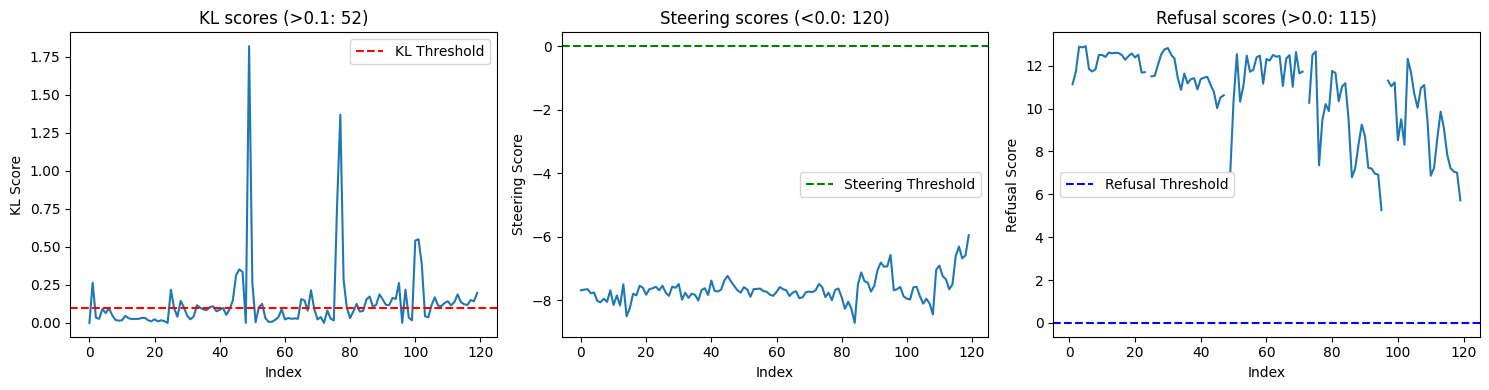

In [16]:
import matplotlib.pyplot as plt
import re

# --- KL scores ---
# Extract KL scores from log_text
kl_scores = []
for line in log_text.splitlines():
    line = line.strip()
    # Try to extract "kl=" style
    if "kl=" in line:
        kl_start = line.find("kl=") + len("kl=")
        kl_end = line.find(",", kl_start)
        if kl_end == -1:
            kl_end = len(line)
        kl_score = float(line[kl_start:kl_end])
        kl_scores.append(kl_score)
    # Try to extract from JSON-like lines
    elif "kl_score" in line and ":" in line:
        match = re.search(r'"?kl_score"?\s*:\s*([-\d.]+)', line)
        if match:
            kl_scores.append(float(match.group(1)))

kl_threshold = 0.1
count_kl_above_threshold = sum(1 for score in kl_scores if score > kl_threshold)

# --- Steering scores ---
steering_scores = []
for line in log_text.splitlines():
    line = line.strip()
    if "steering=" in line:
        steering_start = line.find("steering=") + len("steering=")
        steering_end = line.find(",", steering_start)
        if steering_end == -1:
            steering_end = len(line)
        steering_score = float(line[steering_start:steering_end])
        steering_scores.append(steering_score)
    elif "steering_score" in line and ":" in line:
        match = re.search(r'"?steering_score"?\s*:\s*([-\d.]+)', line)
        if match:
            steering_scores.append(float(match.group(1)))
steering_threshold = 0.0
count_steering_below_threshold = sum(1 for score in steering_scores if score < steering_threshold)

# --- Refusal scores ---
refusal_scores = []
for line in log_text.splitlines():
    line = line.strip()
    # Try to extract "refusal=" style
    if "refusal=" in line:
        refusal_start = line.find("refusal=") + len("refusal=")
        refusal_end = line.find(",", refusal_start)
        if refusal_end == -1:
            refusal_end = len(line)
        refusal_score = float(line[refusal_start:refusal_end])
        refusal_scores.append(refusal_score)
    # Try to extract from JSON-like lines
    elif "refusal_score" in line and ":" in line:
        match = re.search(r'"?refusal_score"?\s*:\s*([-\d.]+)', line)
        if match:
            refusal_scores.append(float(match.group(1)))
refusal_threshold = 0.0
count_refusal_above_threshold = sum(1 for score in refusal_scores if score > refusal_threshold)

# --- Plotting ---
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.plot(kl_scores)
plt.axhline(y=kl_threshold, color='r', linestyle='--', label='KL Threshold')
plt.title(f"KL scores (>{kl_threshold}: {count_kl_above_threshold})")
plt.xlabel("Index")
plt.ylabel("KL Score")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(steering_scores)
plt.axhline(y=steering_threshold, color='g', linestyle='--', label='Steering Threshold')
plt.title(f"Steering scores (<{steering_threshold}: {count_steering_below_threshold})")
plt.xlabel("Index")
plt.ylabel("Steering Score")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(refusal_scores)
plt.axhline(y=refusal_threshold, color='b', linestyle='--', label='Refusal Threshold')
plt.title(f"Refusal scores (>{refusal_threshold}: {count_refusal_above_threshold})")
plt.xlabel("Index")
plt.ylabel("Refusal Score")
plt.legend()

plt.tight_layout()
print(f"Number of KL scores above threshold: {count_kl_above_threshold}")
print(f"Number of steering scores below threshold: {count_steering_below_threshold}")
print(f"Number of refusal scores above threshold: {count_refusal_above_threshold}")
plt.show()


In [18]:
from pipeline.submodules.select_direction import get_refusal_scores
from pipeline.config import Config
from pipeline.model_utils.model_factory import construct_model_base
from pipeline.run_pipeline import load_and_sample_datasets, filter_data
import os
batch_size = 32
model_path = 'Qwen/Qwen-1_8B-chat'
model_alias = os.path.basename(model_path)
cfg = Config(model_alias=model_alias, model_path=model_path)

model_base = construct_model_base(cfg.model_path)


harmful_train, harmless_train, harmful_val, harmless_val = load_and_sample_datasets(cfg)
print(len(harmful_train), len(harmless_train), len(harmful_val), len(harmless_val))
    
harmful_train, harmless_train, harmful_val, harmless_val = filter_data(cfg, model_base, harmful_train, harmless_train, harmful_val, harmless_val)
print(len(harmful_train), len(harmless_train), len(harmful_val), len(harmless_val))

no_ablation_refusal_scores = get_refusal_scores(model_base.model, harmful_train, model_base.tokenize_instructions_fn, model_base.refusal_toks, fwd_pre_hooks=[], fwd_hooks=[], batch_size=batch_size)
no_steering_refusal_scores = get_refusal_scores(model_base.model, harmless_train, model_base.tokenize_instructions_fn, model_base.refusal_toks, fwd_pre_hooks=[], fwd_hooks=[], batch_size=batch_size)

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

/home/kartik/refusal_direction/venv/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


128 128 32 32
112 123 25 31


In [22]:
len(no_ablation_refusal_scores), len(no_steering_refusal_scores)

(112, 123)

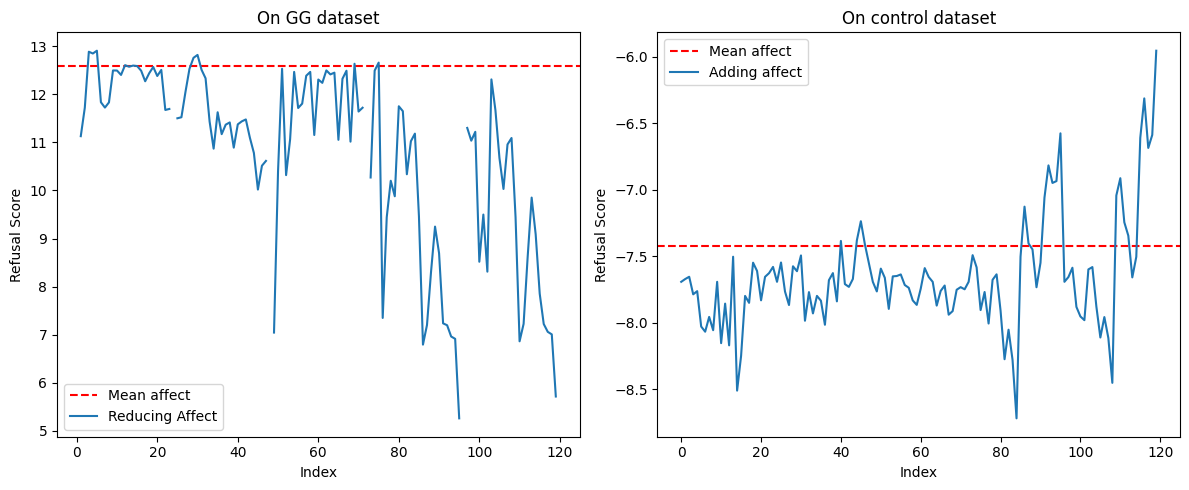

In [38]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
import numpy as np
# Left: Ablation Refusal Scores
no_ablation_refusal_mean = np.array(no_ablation_refusal_scores.cpu().tolist()).mean(axis=0)
axs[0].axhline(y=no_ablation_refusal_mean.mean(), color='r', linestyle='--', label="Mean affect")
axs[0].plot(refusal_scores, label="Reducing Affect")
axs[0].set_title("On GG dataset")
axs[0].set_xlabel("Index")
axs[0].set_ylabel("Refusal Score")
axs[0].legend()

# Right: Steering Refusal Scores
no_steering_refusal_mean = np.array(no_steering_refusal_scores.cpu().tolist()).mean(axis=0)
axs[1].axhline(y=no_steering_refusal_mean.mean(), color='r', linestyle='--', label="Mean affect")
axs[1].plot(steering_scores, label="Adding affect")
axs[1].set_title("On control dataset")
axs[1].set_xlabel("Index")
axs[1].set_ylabel("Refusal Score")
axs[1].legend()

plt.tight_layout()
plt.show()

In [24]:
len(refusal_scores), len(steering_scores)

(120, 120)